# 04. 품목별 예측 전략 분기

03번에서 품목마다 판정이 갈렸다.

- 모델이 나은 품목: 미나리(7/7) · 배추(7/7) · 파(5/7)
- naive 가 나은 품목: 감자(4/7) · 양파(3/7) · 생강(2/7)

이제 이 판정을 **규칙으로** 만든다. 품목명을 코드에 박으면 품목이 늘 때마다
사람이 다시 판정해야 하고, 같은 품목도 시간이 지나면 성격이 바뀔 수 있다.

## 여기서 조심할 함정

**03번 결과를 보고 품목을 고르면 그 자체가 룩어헤드다.** "미나리는 7/7 이니까
모델을 쓰자"는 판단은 2023~2026 전체 성적을 이미 본 뒤의 선택이다. 실제
운영에서는 2023년 초에 그 정보가 없다.

그래서 규칙을 **각 폴드 시점의 정보만으로** 계산한다.

- **정체율** : 그 폴드의 `train` 구간에서만 잰다 (과거 정보라 사용 가능)
- **승률** : **이전 폴드들의 결과만** 누적해서 쓴다 (첫 폴드엔 없으므로 판정 보류)

비교군으로 **oracle**(폴드마다 사후적으로 더 나은 쪽)도 같이 낸다. 이건 실제로
달성 불가능한 **상한선**이고, 규칙이 거기서 얼마나 떨어지는지 보는 용도다.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import font_manager
from sklearn.ensemble import HistGradientBoostingRegressor

_available = {f.name for f in font_manager.fontManager.ttflist}
for _f in ("AppleGothic", "Apple SD Gothic Neo", "NanumGothic", "Malgun Gothic"):
    if _f in _available:
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False
sns.set_style("whitegrid", {"font.family": plt.rcParams["font.family"]})

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
df = pd.read_parquet(ROOT / "notebooks" / ".cache" / "mart.parquet")
df["price_date"] = pd.to_datetime(df["price_date"])
df = df.sort_values(["item", "price_date"]).reset_index(drop=True)
items = sorted(df.item.unique())

H = 7
EXO = ["temp_avg", "temp_min", "temp_max", "precip_mm_avg", "precip_mm_max",
       "humidity_avg", "sunshine_hr_avg", "shipment_qty", "shipment_qty_w1ago"]
CAL = ["month", "dayofweek", "days_to_major_holiday", "days_since_major_holiday",
       "days_since_solar_term"]


def build(src, h=H):
    d = src.copy()
    d["_logp"] = np.log(d.price_kg_avg)

    def g(col):
        return d.groupby("item")[col]

    d["y"] = g("_logp").shift(-h) - d._logp
    for lag in (1, 2, 3, 5, 10, 20):
        d[f"ret{lag}"] = d._logp - g("_logp").shift(lag)
    for w in (5, 20, 60):
        mp = max(2, w // 3)
        d[f"dev{w}"] = d._logp - g("_logp").transform(
            lambda s: s.rolling(w, min_periods=mp).mean())
        d[f"vol{w}"] = g("_logp").transform(
            lambda s: s.diff().rolling(w, min_periods=mp).std())
    for c in EXO:
        d[f"{c}_l1"] = g(c).shift(1)
        d[f"{c}_d20"] = d[f"{c}_l1"] - g(c).transform(
            lambda s: s.shift(1).rolling(20, min_periods=7).mean())
    d["item_code"] = pd.Categorical(d.item, categories=items).codes
    return d


FEATS = ([f"ret{l}" for l in (1, 2, 3, 5, 10, 20)]
         + [f"dev{w}" for w in (5, 20, 60)] + [f"vol{w}" for w in (5, 20, 60)]
         + [f"{c}_l1" for c in EXO] + [f"{c}_d20" for c in EXO]
         + CAL + ["item_code"])
CAT_IDX = [FEATS.index(c) for c in ("item_code", "month", "dayofweek")]
PARAMS = dict(loss="absolute_error", max_iter=400, learning_rate=0.05,
              max_leaf_nodes=15, min_samples_leaf=40, l2_regularization=1.0,
              categorical_features=CAT_IDX, early_stopping=False, random_state=42)

feat = build(df).dropna(subset=["y"])
print(f"{len(feat):,}행 | 피처 {len(FEATS)}개")

8,178행 | 피처 36개


## 1. 규칙

두 신호를 쓴다. **둘 다 그 시점에 계산 가능한 값이다.**

| 신호 | 계산 위치 | 뜻 |
|---|---|---|
| 정체율 | 그 폴드의 train | 전일과 가격이 같은 날의 비율. 높으면 예측할 변동이 없다 |
| 과거 승률 | 이전 폴드들 | 지금까지 모델이 naive 를 이긴 비율 |

**규칙 A (정체율만)** — 첫 폴드부터 쓸 수 있다.
- 정체율 >= 20% 면 naive, 아니면 모델

**규칙 B (정체율 + 승률)** — 이전 폴드가 2개 이상 쌓이면 승률도 본다.
- 정체율 >= 20% → naive
- 관측 폴드 >= 2 이고 과거 승률 < 0.5 → naive
- 그 외 → 모델

임계값 20%/0.5 는 **자의적이다.** 01번에서 잰 정체율이 생강 58.2% · 양파 22.6% ·
나머지 5~11% 로 뚜렷하게 갈려서 그 사이인 20% 를 뒀다. 이런 문턱은 품목이
늘면 다시 봐야 한다.

In [2]:
STALE_TH, WIN_TH, MIN_FOLDS = 0.20, 0.5, 2

FOLDS = [("2023-01-01", "2023-06-30"), ("2023-07-01", "2023-12-31"),
         ("2024-01-01", "2024-06-30"), ("2024-07-01", "2024-12-31"),
         ("2025-01-01", "2025-06-30"), ("2025-07-01", "2025-12-31"),
         ("2026-01-01", "2026-12-31")]
EMBARGO = pd.Timedelta(days=int(H * 1.5))


def ape(part, y_pred):
    """행별 절대백분율오차. 어떤 조합으로도 집계할 수 있게 행 단위로 남긴다."""
    y_pred = np.asarray(y_pred, dtype=float)
    actual = part.price_kg_avg.values * np.exp(part.y.values)
    pred = part.price_kg_avg.values * np.exp(y_pred)
    return np.abs(pred - actual) / actual


recs, hist = [], []   # hist: 이전 폴드들의 (item, 모델이 이겼는가)
for s, e in FOLDS:
    s, e = pd.Timestamp(s), pd.Timestamp(e)
    tr = feat[feat.price_date < s - EMBARGO]
    te = feat[(feat.price_date >= s) & (feat.price_date <= e)]
    if te.empty:
        continue
    label = f"{s:%Y}H{1 if s.month < 7 else 2}"

    # (1) 그 시점에 알 수 있는 신호만으로 판정한다
    stale = tr.groupby("item").price_kg_avg.apply(lambda x: (x.diff() == 0).mean())
    past = pd.DataFrame(hist)
    winrate = past.groupby("item").won.mean() if len(past) else pd.Series(dtype=float)
    nfold = past.groupby("item").won.count() if len(past) else pd.Series(dtype=float)

    m = HistGradientBoostingRegressor(**PARAMS).fit(tr[FEATS], tr.y)
    pred = m.predict(te[FEATS])

    for it in items:
        mask = (te.item == it).values
        e_naive = ape(te[mask], np.zeros(int(mask.sum())))
        e_model = ape(te[mask], pred[mask])
        st = float(stale.get(it, 0.0))
        wr = float(winrate.get(it, np.nan))
        nf = float(nfold.get(it, 0))

        route_a = "naive" if st >= STALE_TH else "model"
        route_b = ("naive" if st >= STALE_TH
                   else "naive" if (nf >= MIN_FOLDS and wr < WIN_TH) else "model")

        recs.append({"fold": label, "item": it, "정체율": st, "과거승률": wr,
                     "관측폴드": nf, "규칙A": route_a, "규칙B": route_b,
                     "naive": e_naive.mean() * 100, "model": e_model.mean() * 100})
        hist.append({"item": it, "won": e_model.mean() < e_naive.mean()})

rt = pd.DataFrame(recs)
print(f"폴드 {rt.fold.nunique()} × 품목 {rt.item.nunique()} = {len(rt)}건")
display(rt.head(6).round(3))

폴드 7 × 품목 6 = 42건


,fold,item,정체율,과거승률,관측폴드,규칙A,규칙B,naive,model
0,2023H1,감자,0.209,NaN,0.0,naive,naive,10.114,9.662
1,2023H1,미나리,0.062,NaN,0.0,model,model,10.678,10.369
2,2023H1,배추,0.105,NaN,0.0,model,model,10.364,10.125
3,2023H1,생강,0.686,NaN,0.0,naive,naive,1.721,2.185
4,2023H1,양파,0.370,NaN,0.0,naive,naive,8.006,8.638
5,2023H1,파,0.084,NaN,0.0,model,model,12.121,10.031


## 2. 규칙이 실제로 무엇을 골랐나

규칙 B 는 폴드가 쌓이면서 판정을 바꿀 수 있다. **어느 시점에 어떤 품목이
naive 로 넘어갔는지** 보면 규칙이 일하는 방식이 드러난다.

=== 규칙A 선택 ===


fold,2023H1,2023H2,2024H1,2024H2,2025H1,2025H2,2026H1
item,,,,,,,
감자,naive,model,model,model,model,model,model
미나리,model,model,model,model,model,model,model
배추,model,model,model,model,model,model,model
생강,naive,naive,naive,naive,naive,naive,naive
양파,naive,naive,naive,naive,naive,naive,naive
파,model,model,model,model,model,model,model


=== 규칙B 선택 ===


fold,2023H1,2023H2,2024H1,2024H2,2025H1,2025H2,2026H1
item,,,,,,,
감자,naive,model,model,model,model,naive,model
미나리,model,model,model,model,model,model,model
배추,model,model,model,model,model,model,model
생강,naive,naive,naive,naive,naive,naive,naive
양파,naive,naive,naive,naive,naive,naive,naive
파,model,model,model,model,model,model,model


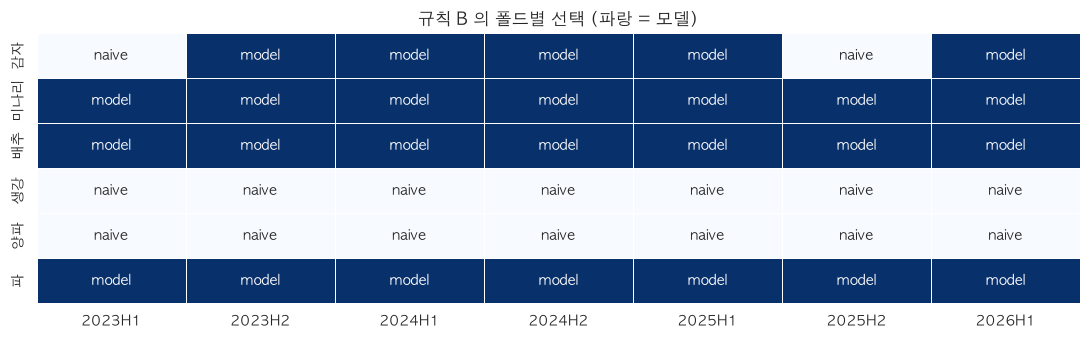

In [3]:
for col in ("규칙A", "규칙B"):
    print(f"=== {col} 선택 ===")
    display(rt.pivot(index="item", columns="fold", values=col))

sel = rt.pivot(index="item", columns="fold", values="규칙B")
fig, ax = plt.subplots(figsize=(11, 3.5))
sns.heatmap(sel.replace({"model": 1, "naive": 0}).astype(int),
            annot=sel.values, fmt="", cmap="Blues", cbar=False,
            ax=ax, linewidths=0.5)
ax.set_title("규칙 B 의 폴드별 선택 (파랑 = 모델)")
ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 3. 전략 비교

다섯 가지를 같은 폴드·같은 행에서 비교한다.

- **all-naive** : 전부 값 유지
- **all-model** : 전부 모델 (02번 방식)
- **규칙 A** : 정체율만
- **규칙 B** : 정체율 + 과거 승률
- **oracle** : 폴드마다 사후적으로 더 나은 쪽 (달성 불가능한 상한선)

In [4]:
rt["all-naive"] = rt.naive
rt["all-model"] = rt.model
rt["규칙A적용"] = np.where(rt.규칙A == "naive", rt.naive, rt.model)
rt["규칙B적용"] = np.where(rt.규칙B == "naive", rt.naive, rt.model)
rt["oracle"] = rt[["naive", "model"]].min(axis=1)

strategies = ["all-naive", "all-model", "규칙A적용", "규칙B적용", "oracle"]
cmp = rt.groupby("item")[strategies].mean().round(2)
cmp.loc["— 전체평균 —"] = rt[strategies].mean().round(2)
display(cmp)

overall = rt[strategies].mean()
print("\nall-naive 대비 개선(%) — 음수가 개선:")
print(((overall / overall["all-naive"] - 1) * 100).round(2).to_string())

,all-naive,all-model,규칙A적용,규칙B적용,oracle
item,,,,,
감자,7.28,7.22,7.28,7.34,7.06
미나리,12.23,10.45,10.45,10.45,10.45
배추,13.81,12.19,12.19,12.19,12.19
생강,2.85,2.75,2.85,2.85,2.53
양파,5.66,5.77,5.66,5.66,5.47
파,11.08,10.18,10.18,10.18,9.92
— 전체평균 —,8.82,8.09,8.10,8.11,7.94



all-naive 대비 개선(%) — 음수가 개선:
all-naive    0.00
all-model   -8.22
규칙A적용       -8.12
규칙B적용       -8.01
oracle      -9.97


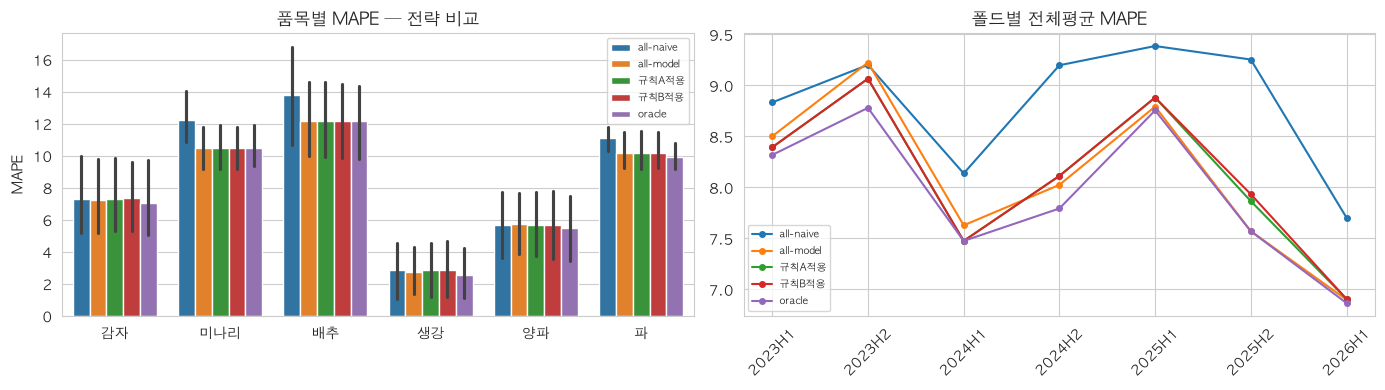

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

melt = rt.melt(id_vars=["fold", "item"], value_vars=strategies,
               var_name="전략", value_name="MAPE")
sns.barplot(data=melt, x="item", y="MAPE", hue="전략", ax=axes[0])
axes[0].set_title("품목별 MAPE — 전략 비교")
axes[0].set_xlabel(""); axes[0].legend(fontsize=7)

fold_mean = rt.groupby("fold")[strategies].mean()
for c in strategies:
    axes[1].plot(fold_mean.index, fold_mean[c], marker="o", ms=4, label=c)
axes[1].set_title("폴드별 전체평균 MAPE")
axes[1].tick_params(axis="x", rotation=45); axes[1].legend(fontsize=7)
plt.tight_layout()
plt.show()

## 4. 정리

### 결과 — 규칙은 전 품목 모델을 이기지 못했다

전체평균 MAPE: all-naive **8.82** · all-model **8.09** · 규칙A **8.10** ·
규칙B **8.11** · oracle **7.94**

규칙을 넣은 쪽이 아무것도 안 한 all-model 보다 **미세하게 나쁘다**(8.10/8.11 vs 8.09).
분기하려던 시도가 실패한 것이다.

### 왜 실패했나 — 03번의 판정 지표가 왜곡이었다

| 품목 | 03번 판정 (평균 개선%) | 04번 절대 MAPE | 실제 |
|---|---|---|---|
| 생강 | +20.50% → naive | 7.28 vs **2.75** (naive 2.85) | **모델이 낫다** |
| 감자 | +0.85% → naive | naive 7.28 vs **model 7.22** | **모델이 낫다** |
| 양파 | +4.34% → naive | **naive 5.66** vs model 5.77 | naive 가 맞다 |

**03번은 폴드별 "개선 비율"의 평균으로 판정했다.** 그런데 MAPE 자체가 이미
백분율이라, 그 비율 개선을 다시 평균 내면 **이중 정규화**가 된다.

생강이 대표적이다. naive MAPE 가 1.7~3 으로 매우 낮아서, 절대 오차가 0.4 만
늘어도 비율로는 +23% 로 보인다. 반대로 다른 폴드에서 0.5 를 줄여도 -12% 로만
보인다. 그래서 **비율 평균은 +20.5%(최악)인데 절대 평균은 오히려 개선**이다.

교훈: **오차 수준이 품목마다 다를 때 "개선 비율의 평균"으로 판정하지 말 것.**
MAPE 는 이미 스케일이 정규화된 지표이므로 절대값으로 비교하는 편이 맞다.

### 분기의 여지 자체가 작았다

oracle(사후적 최선) 7.94 vs all-model 8.09 — 차이가 **0.15** 다. 완벽하게
품목을 골라도 이만큼밖에 못 얻는데, 불완전한 규칙으로 그걸 노리다 오히려
잃었다. 실제로 규칙 B 는 2025H2 에서 감자를 naive 로 돌렸다가 손해를 봤다.

### 결론

**전 품목에 모델을 쓴다. 분기 규칙은 넣지 않는다.**

- 명확히 이득: 미나리(12.23→10.45) · 배추(13.81→12.19) · 파(11.08→10.18)
- 근소한 이득: 감자(7.28→7.22) · 생강(2.85→2.75)
- 유일한 손해: 양파(5.66→5.77). 차이가 0.11 로 작아 규칙을 둘 값어치는 없지만
  **주시 대상**이다. 양파만 따로 손보는 건 나중에 근거가 더 쌓이면 판단한다.

### 이 노트북에서 지킨 것

규칙 판정에 **미래를 쓰지 않았다.** 정체율은 그 폴드의 train 에서만 재고,
승률은 이전 폴드 결과만 누적했다. 03번 결과를 보고 품목을 고르는 방식이었다면
oracle 에 가까운 숫자가 나왔겠지만 그건 실제로 달성 불가능한 값이다.
**규칙이 실패했다는 결론 자체가 이 정직한 설정 덕분에 나왔다.**

### 다음

1. **하이퍼파라미터 튜닝** — 이제 평가 틀(walk-forward + 절대 MAPE)이 정리됐다.
   분기로 얻을 게 없다는 것도 확인됐으니, 남은 개선은 모델 자체에서 나와야 한다.
2. **양파 관찰** — 유일하게 모델이 해로운 품목. 잔차가 특정 시기에 몰리는지 보고,
   그렇다면 수입량(관세청)을 붙일 근거가 된다.
3. 03번 정리의 품목 판정은 이 노트북 기준으로 읽을 것.
